# agentv6_persistence_checkpointer — Durable State with Checkpointer

This version introduces LangGraph persistence.

Graph shape:

```text
START → assistant → END
```

The graph shape is intentionally simple. The new concept is not routing; it is durable state.

In `agentv5_state_memory`, you manually passed message history.

In `agentv6_persistence_checkpointer`, LangGraph reloads prior state by `thread_id`.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```

Use your existing root-level `.env`.


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables

Required:

```env
OPENAI_API_KEY=your_openai_api_key
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=your_langsmith_api_key
LANGSMITH_PROJECT=langgraph-playground
```


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("Current directory:", cwd)
print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


Current directory: /home/aimlnode/Workplace/Projects/langgraph-playground/langgraph-playground-v1-notebook/agentv6_persistence_checkpointer
OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define message state

Same as v5, we use `add_messages`.

This keeps appending new messages to the existing message history.


In [4]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


## 4. Define assistant node

The assistant receives the current checkpointed message state and returns one new AI message.


In [5]:
from langchain_openai import ChatOpenAI

def assistant_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


## 5. Create checkpointer

`InMemorySaver` stores checkpoints in process memory.

It is good for learning and local tests. It is not durable across process restarts.


In [6]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


## 6. Build graph with checkpointer

Persistence is enabled at compile time:

```python
graph.compile(checkpointer=checkpointer)
```


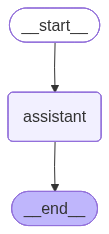

In [7]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("assistant", assistant_node)
    graph_builder.add_edge(START, "assistant")
    graph_builder.add_edge("assistant", END)

    return graph_builder.compile(checkpointer=checkpointer)

graph = build_graph()
graph


## 7. Visualize Mermaid graph


In [8]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 8. Visualize PNG graph


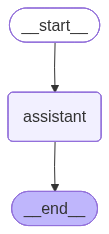

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 9. Understand `thread_id`

A `thread_id` identifies one persisted conversation or workflow instance.

Same `thread_id` means continue the same state.

Different `thread_id` means separate state.


In [10]:
from langchain_core.messages import HumanMessage

thread_id = "sam-demo-thread"

config = {
    "configurable": {
        "thread_id": thread_id
    }
}

config


{'configurable': {'thread_id': 'sam-demo-thread'}}

## 10. First turn

We only pass the new user message.

We do not manually pass old history.


In [11]:
state1 = graph.invoke(
    {"messages": [HumanMessage(content="My name is Sam. Remember it for this conversation.")]},
    config=config,
)

for msg in state1["messages"]:
    print(type(msg).__name__, ":", msg.content)


HumanMessage : My name is Sam. Remember it for this conversation.
AIMessage : Got it, Sam! How can I assist you today?


## 11. Second turn with same thread_id

We again pass only the new message. LangGraph loads previous messages from the checkpoint.


In [12]:
state2 = graph.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config=config,
)

for msg in state2["messages"]:
    print(type(msg).__name__, ":", msg.content)


HumanMessage : My name is Sam. Remember it for this conversation.
AIMessage : Got it, Sam! How can I assist you today?
HumanMessage : What is my name?
AIMessage : Your name is Sam. How can I help you today?


## 12. Compare with a new thread_id

A different `thread_id` starts separate state.


In [13]:
new_thread_config = {
    "configurable": {
        "thread_id": "separate-thread"
    }
}

separate_state = graph.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config=new_thread_config,
)

for msg in separate_state["messages"]:
    print(type(msg).__name__, ":", msg.content)


HumanMessage : What is my name?
AIMessage : I'm sorry, but I don't have access to personal information about you unless you share it with me. How can I assist you today?


## 13. Inspect checkpointed state

`get_state(config)` lets you inspect the current saved state for a thread.


In [14]:
saved_state = graph.get_state(config)

print("Checkpoint values keys:", saved_state.values.keys())
print("Message count:", len(saved_state.values["messages"]))

for msg in saved_state.values["messages"]:
    print(type(msg).__name__, ":", msg.content)


Checkpoint values keys: dict_keys(['messages'])
Message count: 4
HumanMessage : My name is Sam. Remember it for this conversation.
AIMessage : Got it, Sam! How can I assist you today?
HumanMessage : What is my name?
AIMessage : Your name is Sam. How can I help you today?


## 14. Helper function for persistent turns


In [ ]:
def run_turn(thread_id: str, user_input: str) -> AgentState:
    turn_config = {"configurable": {"thread_id": thread_id}}
    return graph.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=turn_config,
    )

state = run_turn("helper-thread", "My favorite cloud is AWS.")
state = run_turn("helper-thread", "What is my favorite cloud?")

state["messages"][-1].content


## 15. Why this matters

Durable state enables:

- real chat sessions
- long-running workflows
- human-in-the-loop resume
- approval flows
- interrupted agents
- multi-step automation
- A2A workflows with shared thread state


## 16. Check LangSmith traces

Open LangSmith project:

```text
langgraph-playground
```

Inspect the ChatOpenAI input messages for the second turn. You should see the earlier name-setting message included.


## 17. What changed from v5 to v6

v5:

```text
You manually pass prior messages
```

v6:

```text
Checkpointer reloads prior messages by thread_id
```
